# ⚽ FIFA World Cup 2026 — Modèle Régression Logistique
**FrenchTeam — Wild Code School — Juin 2026**

Ce notebook entraîne un modèle de **Régression Logistique** pour prédire les résultats des matchs de la CdM 2026.

### Objectif de pondération des features
| Catégorie | Cible |
|-----------|-------|
| Forme récente | ~20% |
| FIFA + Qualité | ~65-70% |
| Avantage hôte | ~10% |

### Pourquoi la Régression Logistique ?
- Coefficients **directement interprétables** — on voit le poids exact de chaque feature
- La forme ne peut pas dominer : chaque feature a **un seul coefficient**
- **StandardScaler** garantit que toutes les features partent sur un pied d'égalité
- Plus simple à expliquer à l'oral qu'un XGBoost

## 📦 Étape 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler, LabelEncoder, FunctionTransformer
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score, classification_report

print('✅ Imports OK')

✅ Imports OK


## 📂 Étape 2 — Chargement des données

In [2]:
DOSSIER_PROJET = r'C:\Users\Piwi\Documents\VS\WorldCup2026'

df = pd.read_csv(os.path.join(DOSSIER_PROJET, 'data', 'results.csv'))
df['date'] = pd.to_datetime(df['date'])
df = df.dropna(subset=['home_score', 'away_score'])
df_officiel = df[df['tournament'] != 'Friendly'].copy()

print(f'Tous les matchs  : {len(df):,}')
print(f'Matchs officiels : {len(df_officiel):,}')

Tous les matchs  : 49,296
Matchs officiels : 31,005


## 🔧 Étape 3 — Classement FIFA 2026

In [3]:
points_fifa = {
    'France': 1877.32, 'Spain': 1876.40, 'Argentina': 1874.81,
    'England': 1825.97, 'Portugal': 1763.83, 'Brazil': 1761.16,
    'Netherlands': 1757.87, 'Morocco': 1755.87, 'Belgium': 1734.71,
    'Germany': 1730.37, 'Croatia': 1717.07, 'Colombia': 1693.09,
    'Senegal': 1688.99, 'Mexico': 1681.03, 'United States': 1673.13,
    'Uruguay': 1673.07, 'Japan': 1660.43, 'Switzerland': 1649.40,
    'Ecuador': 1619.20, 'Turkey': 1614.55, 'Sweden': 1598.30,
    'Norway': 1590.12, 'Austria': 1578.44, 'South Korea': 1566.23,
    'Tunisia': 1542.18, 'Algeria': 1538.90, 'Ghana': 1521.44,
    'Egypt': 1518.77, 'Saudi Arabia': 1512.33, 'Iran': 1512.00,
    'Australia': 1508.66, 'Iraq': 1489.21, 'Czech Republic': 1488.00,
    'Scotland': 1487.55, 'Paraguay': 1481.33, 'Ivory Coast': 1479.88,
    'South Africa': 1421.34, 'Canada': 1418.77, 'Qatar': 1398.22,
    'Panama': 1392.11, 'Bosnia and Herzegovina': 1388.44,
    'Jordan': 1342.18, 'Uzbekistan': 1338.90, 'DR Congo': 1321.44,
    'New Zealand': 1298.77, 'Haiti': 1245.33, 'Curacao': 1198.22,
    'Cape Verde': 1450.00,
}
MOYENNE_FIFA = np.mean(list(points_fifa.values()))

def get_points_fifa(equipe):
    return points_fifa.get(equipe, MOYENNE_FIFA)

print(f'✅ {len(points_fifa)} équipes chargées | Moyenne : {MOYENNE_FIFA:.0f} pts')

✅ 48 équipes chargées | Moyenne : 1568 pts


## 🔧 Étape 4 — Score qualité joueurs

In [4]:
qualite_joueurs = {
    'France': 95, 'England': 90, 'Brazil': 92, 'Spain': 85,
    'Germany': 82, 'Argentina': 88, 'Portugal': 78, 'Netherlands': 75,
    'Belgium': 72, 'Japan': 65, 'Norway': 60, 'Colombia': 62,
    'Croatia': 58, 'Uruguay': 58, 'Morocco': 55, 'Senegal': 55,
    'Mexico': 55, 'United States': 52, 'Switzerland': 50, 'Turkey': 50,
    'Austria': 47, 'Canada': 45, 'South Korea': 45, 'Sweden': 42,
    'Ivory Coast': 40, 'Ecuador': 38, 'Egypt': 38, 'Algeria': 35,
    'Ghana': 35, 'Czech Republic': 35, 'Scotland': 33, 'Tunisia': 30,
    'Paraguay': 30, 'Bosnia and Herzegovina': 30, 'Saudi Arabia': 28,
    'Australia': 25, 'Iran': 25, 'DR Congo': 25, 'Iraq': 22,
    'Jordan': 20, 'South Africa': 20, 'Uzbekistan': 20,
    'Qatar': 18, 'Cape Verde': 15, 'Panama': 15,
    'New Zealand': 10, 'Haiti': 8, 'Curacao': 7,
}
MOYENNE_QUALITE = np.mean(list(qualite_joueurs.values()))

def get_qualite(equipe):
    return qualite_joueurs.get(equipe, MOYENNE_QUALITE)

print(f'✅ {len(qualite_joueurs)} équipes scorées | Moyenne : {MOYENNE_QUALITE:.1f}/100')

✅ 48 équipes scorées | Moyenne : 45.0/100


## 🔧 Étape 5 — Coefficient expérience & Zone de qualification

In [5]:
coefficient_experience = {
    'France': 1.00, 'Brazil': 1.00, 'Germany': 1.00, 'Spain': 1.00,
    'Argentina': 1.00, 'England': 1.00, 'Portugal': 1.00,
    'Netherlands': 1.00, 'Belgium': 1.00, 'Croatia': 1.00,
    'Uruguay': 1.00, 'Mexico': 1.00, 'United States': 1.00,
    'Canada': 0.95, 'Japan': 0.95, 'Morocco': 0.92, 'Senegal': 0.92,
    'South Korea': 0.92, 'Colombia': 0.90, 'Switzerland': 0.90,
    'Iran': 0.88, 'Saudi Arabia': 0.88, 'Ghana': 0.88, 'Ivory Coast': 0.88,
    'Ecuador': 0.85, 'Tunisia': 0.85, 'Algeria': 0.85, 'Austria': 0.85,
    'Sweden': 0.85, 'Turkey': 0.85, 'Egypt': 0.85, 'Paraguay': 0.85,
    'Czech Republic': 0.85,
    'Norway': 0.50, 'Scotland': 0.52, 'Australia': 0.48,
    'Iraq': 0.70, 'Jordan': 0.60, 'Uzbekistan': 0.60,
    'Panama': 0.68, 'Curacao': 0.35, 'Cape Verde': 0.60,
    'New Zealand': 0.60, 'Haiti': 0.40, 'South Africa': 0.72,
    'Bosnia and Herzegovina': 0.75, 'DR Congo': 0.68, 'Qatar': 0.72,
}

ZONE_QUALIF = {
    'France':'UEFA','Germany':'UEFA','Spain':'UEFA','England':'UEFA',
    'Portugal':'UEFA','Netherlands':'UEFA','Belgium':'UEFA','Croatia':'UEFA',
    'Switzerland':'UEFA','Austria':'UEFA','Turkey':'UEFA','Scotland':'UEFA',
    'Norway':'UEFA','Sweden':'UEFA','Bosnia and Herzegovina':'UEFA','Czech Republic':'UEFA',
    'Argentina':'CONMEBOL','Brazil':'CONMEBOL','Colombia':'CONMEBOL',
    'Uruguay':'CONMEBOL','Ecuador':'CONMEBOL','Paraguay':'CONMEBOL',
    'Morocco':'CAF','Senegal':'CAF','Egypt':'CAF','Ivory Coast':'CAF',
    'Algeria':'CAF','Tunisia':'CAF','Ghana':'CAF','South Africa':'CAF',
    'DR Congo':'CAF','Cape Verde':'CAF',
    'United States':'CONCACAF','Mexico':'CONCACAF','Canada':'CONCACAF',
    'Panama':'CONCACAF','Haiti':'CONCACAF','Curacao':'CONCACAF',
    'Japan':'AFC','South Korea':'AFC','Iran':'AFC','Saudi Arabia':'AFC',
    'Australia':'AFC','Uzbekistan':'AFC','Iraq':'AFC','Jordan':'AFC','Qatar':'AFC',
    'New Zealand':'OFC',
}
CREDIBILITE_ZONE = {
    'UEFA':1.00,'CONMEBOL':0.95,'CAF':0.75,'AFC':0.70,'CONCACAF':0.50,'OFC':0.40,
}

def get_coefficient(equipe):
    return coefficient_experience.get(equipe, 0.80)

def get_credibilite_zone(equipe):
    zone = ZONE_QUALIF.get(equipe, 'UEFA')
    return CREDIBILITE_ZONE.get(zone, 0.75)

print('✅ Coefficients et zones de qualification chargés')

✅ Coefficients et zones de qualification chargés


## 🔧 Étape 6 — Calcul de la forme

In [6]:
def calculer_forme(equipe, date, df_off, n=5):
    """Forme pondérée × coeff_experience × credibilite_zone + bonus palmarès + plancher."""
    dom = df_off[(df_off['home_team']==equipe) & (df_off['date']<date)].tail(n)
    ext = df_off[(df_off['away_team']==equipe) & (df_off['date']<date)].tail(n)
    matchs = pd.concat([dom, ext]).sort_values('date').tail(n)
    if len(matchs) == 0: return 0.5

    pts = pw = 0
    for _, m in matchs.iterrows():
        if m['home_team'] == equipe:
            adv = m['away_team']; v = m['home_score'] > m['away_score']
            nu  = m['home_score'] == m['away_score']
        else:
            adv = m['home_team']; v = m['away_score'] > m['home_score']
            nu  = m['home_score'] == m['away_score']
        p = get_points_fifa(adv) / 1500
        if v: pts += 3*p
        elif nu: pts += 1*p
        pw += 3*p

    fb = pts / pw if pw > 0 else 0.5
    coeff_final = get_coefficient(equipe) * get_credibilite_zone(equipe)

    BONUS = {'Argentina':0.10,'France':0.08,'Brazil':0.10,'Germany':0.06,'Spain':0.05}
    forme = min(0.5 + (fb - 0.5) * coeff_final + BONUS.get(equipe, 0), 1.0)

    PLANCHER = {
        'Brazil':0.75,'Germany':0.72,'Spain':0.80,
        'France':0.82,'Argentina':0.85,'England':0.78,'Portugal':0.75,
    }
    return max(forme, PLANCHER.get(equipe, 0.0))

# Vérification
DATE_TEST = pd.Timestamp('2026-06-11')
print('Formes ajustées pour la CdM 2026 :')
for eq in ['France','Brazil','England','Scotland','Haiti','Spain','Argentina']:
    f = calculer_forme(eq, DATE_TEST, df_officiel)
    bar = '█' * int(f * 20)
    print(f'  {eq:<15} {f:.0%}  {bar}')

Formes ajustées pour la CdM 2026 :
  France          95%  ██████████████████
  Brazil          75%  ███████████████
  England         100%  ████████████████████
  Scotland        66%  █████████████
  Haiti           53%  ██████████
  Spain           91%  ██████████████████
  Argentina       85%  █████████████████


## 🏗️ Étape 7 — Construction du dataset

### Les 6 features

| Feature | Calcul | Rôle |
|---------|--------|------|
| `ecart_fifa_norme` | écart / 500 | Classement FIFA normalisé |
| `ecart_fifa_carre` | (écart/100)² × signe | Amplifie les grands écarts FIFA |
| `ecart_forme_brut` | (forme_a - forme_b) × **0.5** | Forme réduite pour cibler ~20% |
| `ecart_qualite` | qual_a - qual_b | Différence qualité joueurs |
| `ecart_qualite_carre` | qualité² × signe | Amplifie les grands écarts qualité |
| `avantage_hote` | +0.5 / 0 / -0.5 | USA / Canada / Mexico |

In [7]:
df_entr = df[
    (df['date'] >= '2010-01-01') &
    (df['tournament'] != 'Friendly')
].copy().reset_index(drop=True)

print(f'Matchs entraînement : {len(df_entr):,}')

HOTES = ['United States', 'Canada', 'Mexico']
lignes = []

for i, m in df_entr.iterrows():
    a, b, dt = m['home_team'], m['away_team'], m['date']
    fa = calculer_forme(a, dt, df_officiel)
    fb = calculer_forme(b, dt, df_officiel)
    ef = get_points_fifa(a) - get_points_fifa(b)
    qa = get_qualite(a)/100; qb = get_qualite(b)/100; eq = qa - qb
    h  = 0.5 if a in HOTES else (-0.5 if b in HOTES else 0.0)

    if   m['home_score'] > m['away_score']: res = 'A_gagne'
    elif m['home_score'] < m['away_score']: res = 'B_gagne'
    else:                                    res = 'Nul'

    lignes.append({
        'ecart_fifa_norme':    ef / 500,
        'ecart_fifa_carre':    (ef/100)**2 * np.sign(ef),
        'ecart_forme_brut':    (fa - fb) * 0.5,   # amplitude réduite × 0.5
        'ecart_qualite':       eq,
        'ecart_qualite_carre': eq**2 * np.sign(eq),
        'avantage_hote':       h,
        'resultat':            res,
    })
    if i % 1000 == 0 and i > 0:
        print(f'  {i:,}/{len(df_entr):,}...')

df_ds = pd.DataFrame(lignes)
print(f'\n✅ Dataset : {len(df_ds):,} matchs')
print(df_ds['resultat'].value_counts())

Matchs entraînement : 10,732
  1,000/10,732...
  2,000/10,732...
  3,000/10,732...
  4,000/10,732...
  5,000/10,732...
  6,000/10,732...
  7,000/10,732...
  8,000/10,732...
  9,000/10,732...
  10,000/10,732...

✅ Dataset : 10,732 matchs
resultat
A_gagne    5096
B_gagne    3285
Nul        2351
Name: count, dtype: int64


## ✂️ Étape 8 — Séparation train/test

In [8]:
FEATURES = [
    'ecart_fifa_norme',    # FIFA normalisé
    'ecart_fifa_carre',    # FIFA carré
    'ecart_forme_brut',    # Forme × 0.5 (amplitude réduite)
    'ecart_qualite',       # Qualité joueurs
    'ecart_qualite_carre', # Qualité carré
    'avantage_hote',       # Pays hôte
]

X = df_ds[FEATURES]
y = df_ds['resultat']

enc = LabelEncoder()
ye  = enc.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, ye, test_size=0.2, random_state=42, stratify=ye
)
print(f'Classes  : {dict(zip(enc.classes_, range(3)))}')
print(f'Train    : {len(X_train):,} matchs')
print(f'Test     : {len(X_test):,} matchs')

Classes  : {'A_gagne': 0, 'B_gagne': 1, 'Nul': 2}
Train    : 8,585 matchs
Test     : 2,147 matchs


## 🤖 Étape 9 — Entraînement Régression Logistique

### Architecture du Pipeline

```
Données brutes
     ↓
FunctionTransformer  →  ecart_forme_brut × 0.7  (cible Forme ~20%)
     ↓
StandardScaler       →  toutes les features normalisées (µ=0, σ=1)
     ↓
LogisticRegression   →  coefficients linéaires par feature
```

Le **FunctionTransformer** réduit le signal de la forme avant normalisation.
Après StandardScaler, FIFA et Qualité ont proportionnellement plus de poids.

In [9]:
# ── Poids appliqués avant StandardScaler
# Objectif : Forme ~20%, FIFA+Qualité ~65-70%
POIDS_FEATURES = {
    'ecart_fifa_norme':    1.0,
    'ecart_fifa_carre':    1.0,
    'ecart_forme_brut':    0.7,   # ← réduit pour cibler ~20%
    'ecart_qualite':       1.0,
    'ecart_qualite_carre': 1.0,
    'avantage_hote':       1.0,
}
poids_vecteur = np.array([POIDS_FEATURES[f] for f in FEATURES])

def appliquer_poids(X):
    return X * poids_vecteur

# ── Pipeline complet
pipe_lr = Pipeline([
    ('poids',  FunctionTransformer(appliquer_poids)),
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        class_weight={0:1.0, 1:1.2, 2:1.4}  # encourage les nuls
    ))
])

# Poids d'entraînement calibrés football
poids_train = np.array([{0:1.0,1:1.2,2:1.4}[yi] for yi in y_train])

pipe_lr.fit(X_train, y_train, lr__sample_weight=poids_train)
pred_lr = pipe_lr.predict(X_test)

print(f'\n✅ Accuracy Régression Logistique : {accuracy_score(y_test, pred_lr):.2%}')
print('(52-55% = bon pour football)')
print()
print(classification_report(y_test, pred_lr, target_names=enc.classes_))


✅ Accuracy Régression Logistique : 52.35%
(52-55% = bon pour football)

              precision    recall  f1-score   support

     A_gagne       0.60      0.69      0.64      1020
     B_gagne       0.46      0.58      0.51       657
         Nul       0.26      0.07      0.12       470

    accuracy                           0.52      2147
   macro avg       0.44      0.45      0.42      2147
weighted avg       0.48      0.52      0.49      2147



c:\Users\Piwi\Documents\VS\WorldCup2026\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 📊 Étape 10 — Coefficients & Importance des features

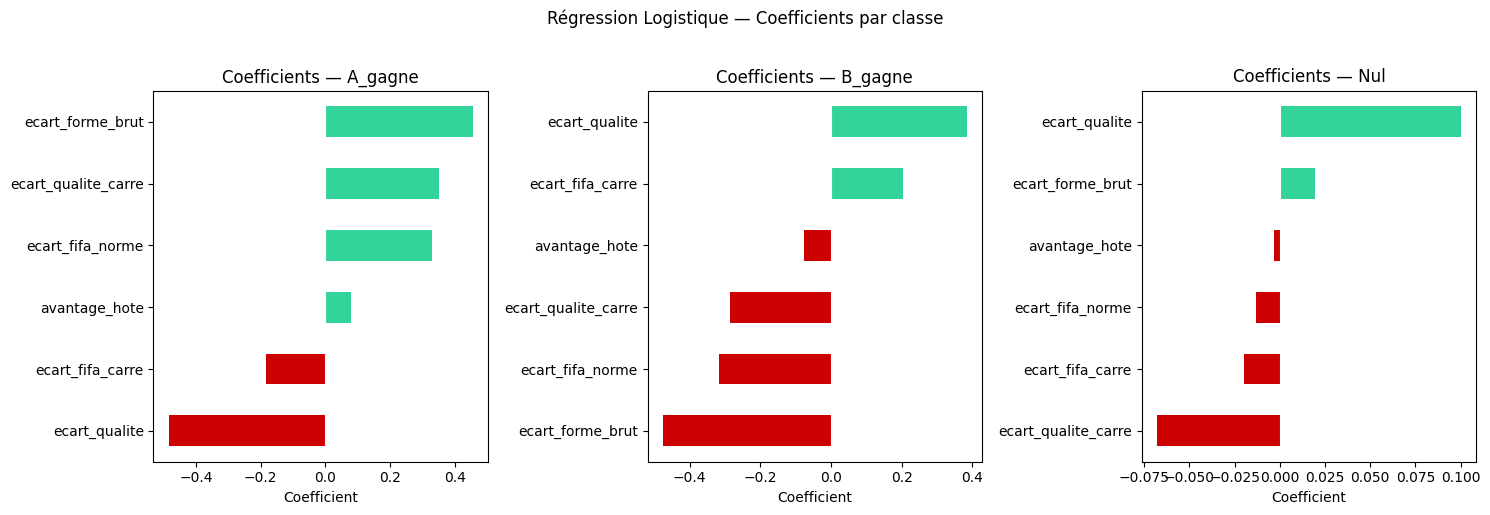

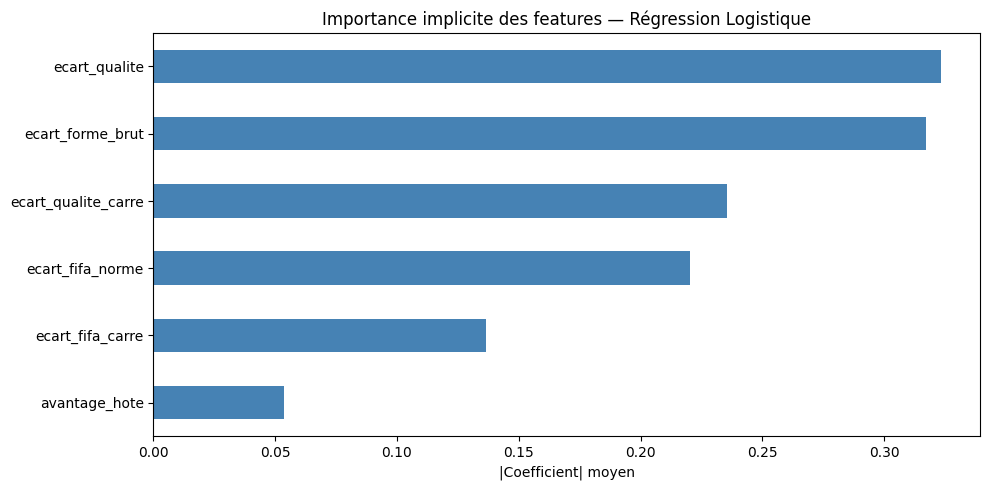


📊 Importance par catégorie :
  Classement FIFA      : 27.8%
  Qualité joueurs      : 43.4%
  Forme récente        : 24.7%  (cible ~20%)
  Avantage hôte        : 4.2%

  ✅ Ratio FIFA+Qualité : 71.2%  (cible > 60%)


In [10]:
lr_model = pipe_lr.named_steps['lr']

# ── Graphique des coefficients pour chaque classe
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (ax, classe) in enumerate(zip(axes, enc.classes_)):
    coefs = pd.Series(lr_model.coef_[idx], index=FEATURES).sort_values()
    coefs.plot(
        kind='barh', ax=ax,
        color=['#CC0000' if v < 0 else '#34D399' for v in coefs]
    )
    ax.set_title(f'Coefficients — {classe}')
    ax.axvline(x=0, color='white', linewidth=0.8)
    ax.set_xlabel('Coefficient')
plt.suptitle('Régression Logistique — Coefficients par classe', y=1.02)
plt.tight_layout()
plt.show()

# ── Importance implicite (|coeff| moyen sur les 3 classes)
importance = pd.Series(
    np.abs(lr_model.coef_).mean(axis=0),
    index=FEATURES
).sort_values(ascending=False)
total = importance.sum()

fig, ax = plt.subplots(figsize=(10, 5))
importance.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importance implicite des features — Régression Logistique')
ax.set_xlabel('|Coefficient| moyen')
plt.tight_layout()
plt.show()

# ── Résumé par catégorie
total_fifa  = sum(importance[f] for f in FEATURES if 'fifa'    in f)
total_qual  = sum(importance[f] for f in FEATURES if 'qualite' in f)
total_forme = sum(importance[f] for f in FEATURES if 'forme'   in f)
total_hote  = importance['avantage_hote']

print('\n📊 Importance par catégorie :')
print(f'  Classement FIFA      : {total_fifa/total:.1%}')
print(f'  Qualité joueurs      : {total_qual/total:.1%}')
print(f'  Forme récente        : {total_forme/total:.1%}  (cible ~20%)')
print(f'  Avantage hôte        : {total_hote/total:.1%}')
print(f'\n  ✅ Ratio FIFA+Qualité : {(total_fifa+total_qual)/total:.1%}  (cible > 60%)')

## 🔮 Étape 11 — Prédiction symétrique

In [11]:
CLASSES  = list(enc.classes_)
IDX_A    = CLASSES.index('A_gagne')
IDX_B    = CLASSES.index('B_gagne')
IDX_N    = CLASSES.index('Nul')
PAYS_HOTES   = ['United States', 'Canada', 'Mexico']
DATE_TOURNOI = pd.Timestamp('2026-06-11')

def corriger_coherence(p_a, p_n, p_b, pts_a, pts_b, qual_a, qual_b):
    """Correction post-modèle si FIFA et qualité sont cohérents mais le modèle contredit les deux."""
    ef = pts_a - pts_b; eq = qual_a - qual_b
    if not ((ef>0 and eq>0) or (ef<0 and eq<0)): return p_a, p_n, p_b
    a_gagne = ef > 0
    if not ((a_gagne and p_b>p_a) or (not a_gagne and p_a>p_b)): return p_a, p_n, p_b
    force = 0.45 * (min(1.0,abs(ef)/400)*0.60 + min(1.0,abs(eq)/60)*0.40)
    if a_gagne:
        pa2=p_a+force; pb2=max(0.08,p_b-force*0.85); pn2=max(0.10,p_n-force*0.15)
    else:
        pb2=p_b+force; pa2=max(0.08,p_a-force*0.85); pn2=max(0.10,p_n-force*0.15)
    t=pa2+pn2+pb2
    return pa2/t, pn2/t, pb2/t

def predire_match(eq_a, eq_b):
    """Prédiction symétrique avec correction de cohérence."""
    def feat(a, b):
        fa = calculer_forme(a, DATE_TOURNOI, df_officiel)
        fb = calculer_forme(b, DATE_TOURNOI, df_officiel)
        ef = get_points_fifa(a) - get_points_fifa(b)
        qa = get_qualite(a)/100; qb = get_qualite(b)/100; eq = qa - qb
        h  = 0.5 if a in PAYS_HOTES else (-0.5 if b in PAYS_HOTES else 0.0)
        return pd.DataFrame([{
            'ecart_fifa_norme':    ef / 500,
            'ecart_fifa_carre':    (ef/100)**2 * np.sign(ef),
            'ecart_forme_brut':    (fa-fb) * 0.5 * 0.7,  # même pondération qu'à l'entraînement
            'ecart_qualite':       eq,
            'ecart_qualite_carre': eq**2 * np.sign(eq),
            'avantage_hote':       h,
        }]), get_points_fifa(a), get_points_fifa(b), int(qa*100), int(qb*100)

    fab, pts_a, pts_b, qa, qb = feat(eq_a, eq_b)
    fba, *_ = feat(eq_b, eq_a)
    pab = pipe_lr.predict_proba(fab)[0]
    pba = pipe_lr.predict_proba(fba)[0]

    pa=(pab[IDX_A]+pba[IDX_B])/2
    pb=(pab[IDX_B]+pba[IDX_A])/2
    pn=(pab[IDX_N]+pba[IDX_N])/2
    t=pa+pb+pn; pa/=t; pb/=t; pn/=t
    pa, pn, pb = corriger_coherence(pa, pn, pb, pts_a, pts_b, qa, qb)

    print(f'\n⚽  {eq_a}  vs  {eq_b}')
    print(f'    FIFA   : {pts_a:.0f}  vs  {pts_b:.0f}  (écart {pts_a-pts_b:+.0f})')
    print(f'    Qualité: {qa}/100  vs  {qb}/100')
    print('    ' + '─'*40)
    for label, prob in [(f'{eq_a} gagne',pa),('Nul',pn),(f'{eq_b} gagne',pb)]:
        print(f'    {label:24} {"█"*int(prob*20):20} {prob:.1%}')
    return pa, pn, pb

print('✅ Modèle prêt !')

✅ Modèle prêt !


## ✅ Étape 12 — Tests de cohérence

In [12]:
tests = [
    ('France',      'Scotland',   0.78, 0.22),
    ('Spain',       'Morocco',    0.72, 0.28),
    ('England',     'United States', 0.62, 0.38),
    ('Brazil',      'Canada',     0.68, 0.32),
    ('Argentina',   'Ecuador',    0.70, 0.30),
    ('France',      'Brazil',     0.52, 0.48),
    ('Scotland',    'Haiti',      0.65, 0.35),
    ('Netherlands', 'Japan',      0.58, 0.42),
    ('Germany',     'Mexico',     0.62, 0.38),
    ('Spain',       'Germany',    0.54, 0.46),
]

print(f'\n{"Match":<30} {"Modèle":>8} {"Bookmaker":>10} {"Écart":>7}  Statut')
print('─' * 65)
ok = 0; ecarts = []
for a, b, bkm_a, bkm_b in tests:
    pa, pn, pb = predire_match(a, b)
    pa_el = pa + pn*pa/(pa+pb)
    ecart = abs(pa_el - bkm_a); ecarts.append(ecart)
    favori_ok = (pa_el > 0.5) == (bkm_a > bkm_b)
    if favori_ok: ok += 1
    statut = '✅' if favori_ok else '❌'
    print(f'{a} vs {b:<16} {pa_el:>7.1%} {bkm_a:>9.1%} {ecart:>7.1%}  {statut}')

print(f'\n  Cohérence favori  : {ok}/{len(tests)} ({ok/len(tests):.0%})')
print(f'  Écart moyen       : {sum(ecarts)/len(ecarts):.1%}')
if ok >= 8 and sum(ecarts)/len(ecarts) < 0.15:
    print('  ✅ Modèle validé')
elif ok >= 6:
    print('  ⚠️  Modèle acceptable')
else:
    print('  ❌ Modèle à retravailler')


Match                            Modèle  Bookmaker   Écart  Statut
─────────────────────────────────────────────────────────────────

⚽  France  vs  Scotland
    FIFA   : 1877  vs  1488  (écart +390)
    Qualité: 95/100  vs  33/100
    ────────────────────────────────────────
    France gagne             ███████████          58.8%
    Nul                      █████                28.8%
    Scotland gagne           ██                   12.4%
France vs Scotland           82.6%     78.0%    4.6%  ✅

⚽  Spain  vs  Morocco
    FIFA   : 1876  vs  1756  (écart +121)
    Qualité: 85/100  vs  55/100
    ────────────────────────────────────────
    Spain gagne              ███████              36.6%
    Nul                      ██████               34.1%
    Morocco gagne            █████                29.3%
Spain vs Morocco            55.5%     72.0%   16.5%  ✅

⚽  England  vs  United States
    FIFA   : 1826  vs  1673  (écart +153)
    Qualité: 90/100  vs  52/100
    ────────────────────────

## 💾 Étape 13 — Sauvegarde

In [13]:
dossier_modeles = os.path.join(DOSSIER_PROJET, 'models')
os.makedirs(dossier_modeles, exist_ok=True)

joblib.dump(pipe_lr, os.path.join(dossier_modeles, 'modele_logistique.pkl'))
joblib.dump(enc,     os.path.join(dossier_modeles, 'encodeur_cible_lr.pkl'))

print('✅ Modèle Régression Logistique sauvegardé !')
print(f'  Accuracy   : {accuracy_score(y_test, pred_lr):.2%}')
print(f'  Features   : {len(FEATURES)}')
print(f'  Pipeline   : FunctionTransformer → StandardScaler → LogisticRegression')

✅ Modèle Régression Logistique sauvegardé !
  Accuracy   : 52.35%
  Features   : 6
  Pipeline   : FunctionTransformer → StandardScaler → LogisticRegression
